# Week 4 – Activity 1: SQL Analysis – World Happiness Report

**Objective:** Write and execute two analytical SQL queries against the World Happiness dataset.

| # | Query | Key SQL Techniques |
|---|---|---|
| 1 | GDP categories → average happiness per category → country rank within category | `CASE/WHEN`, CTE, `AVG()`, `RANK() OVER (PARTITION BY …)` |
| 2 | High vs Low corruption split → multiple averages compared via subquery | Scalar subquery, CTE, multiple `AVG()`, `GROUP BY` |

---
## 1. Setup – Libraries & Database

In [1]:
import sqlite3
import pandas as pd

conn   = sqlite3.connect(':memory:')
cursor = conn.cursor()

print('SQLite version:', sqlite3.sqlite_version)

SQLite version: 3.50.4


---
## 2. Load CSV into SQLite

The dataset contains **20 countries** with eight features:

| Column | Description |
|---|---|
| `Country` | Country name |
| `Happiness_Score` | Ladder score (0–10) |
| `GDP_per_Capita` | Economic output score (WHR scale) |
| `Social_Support` | Perceived social support (0–1) |
| `Healthy_Life_Expectancy` | Healthy life expectancy at birth (years) |
| `Freedom_to_Make_Choices` | Freedom score (0–1) |
| `Generosity` | Generosity score |
| `Perceptions_of_Corruption` | Corruption perception (0–1; higher = more corruption perceived) |

In [2]:
import os

# Load from same folder as this notebook
CSV_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'world_happiness_dataset.csv')
CSV_PATH = r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 4\world_happiness_dataset.csv'

df_raw = pd.read_csv(CSV_PATH)
df_raw.to_sql('happiness', conn, if_exists='replace', index=False)

print(f'Rows loaded: {len(df_raw)}')
df_raw

Rows loaded: 20


,Country,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
0,Norway,6.25,1.39,0.82,81.6,0.69,0.01,0.71
1,Denmark,3.61,1.27,0.43,66.9,0.48,0.43,0.53
2,Iceland,4.68,0.87,0.54,63.4,0.71,0.41,0.72
3,Switzerland,4.46,0.67,0.57,68.8,0.93,0.32,0.52
4,Finland,6.67,1.55,0.45,75.4,0.58,0.16,0.10
5,Netherlands,6.41,0.87,0.54,72.6,0.45,0.38,0.36
6,Canada,7.34,0.60,0.46,49.6,1.00,0.07,0.12
7,New Zealand,3.87,0.61,0.57,41.3,0.66,0.26,0.84
8,Australia,5.31,1.43,0.78,53.2,0.36,0.27,0.80
9,Sweden,3.63,1.16,0.62,51.2,0.33,0.57,0.77


---
## 3. Query 1 — GDP Categories, Average Happiness, and Country Rankings

### Purpose
Group countries into **Low / Medium / High GDP tiers**, calculate the **average happiness score** for each tier, and rank every country within its own tier by happiness score.

---

### Step-by-Step Explanation

#### Step 1 — CTE `categorised`: Assign a GDP category to each country
```sql
CASE
    WHEN GDP_per_Capita >= 1.30 THEN 'High'
    WHEN GDP_per_Capita >= 0.90 THEN 'Medium'
    ELSE                             'Low'
END AS gdp_category
```
The `CASE / WHEN` expression checks each row's `GDP_per_Capita` and labels it:
- **High** — top tier (≥ 1.30), 8 countries
- **Medium** — middle band (0.90 – 1.30), 7 countries
- **Low** — bottom tier (< 0.90), 5 countries

Thresholds are based on the dataset's quartile range (min 0.60, Q1 0.91, Q3 1.40, max 1.57) to create roughly balanced groups.

#### Step 2 — CTE `category_avg`: Average happiness per tier
```sql
SELECT gdp_category,
       ROUND(AVG(Happiness_Score), 4) AS avg_happiness
FROM   categorised
GROUP  BY gdp_category
```
`GROUP BY gdp_category` collapses all countries in each tier into one row, and `AVG()` computes the mean happiness score. `ROUND(…, 4)` keeps the result clean. This CTE is joined back to the main result so every country row also shows its tier's benchmark.

#### Step 3 — Final SELECT: Window function for within-category ranking
```sql
RANK() OVER (
    PARTITION BY c.gdp_category
    ORDER BY c.Happiness_Score DESC
) AS rank_in_category
```
- `PARTITION BY gdp_category` — resets the rank counter for each tier independently.
- `ORDER BY Happiness_Score DESC` — rank 1 = happiest country in that tier.
- `RANK()` assigns equal ranks to ties and leaves gaps afterward (e.g., 1, 2, 2, 4).

The category average from CTE 2 is brought in via `JOIN category_avg ON gdp_category`, adding the tier benchmark to every row without repeating the aggregation.

**Output columns:** `gdp_category | avg_happiness_in_category | Country | Happiness_Score | rank_in_category`

In [3]:
query1 = '''
-- ══════════════════════════════════════════════════════════════════════
-- QUERY 1: GDP Categories  ▸  Avg Happiness per Category  ▸  Country Rank
-- ══════════════════════════════════════════════════════════════════════

-- CTE 1: Assign each country a GDP category using CASE/WHEN
WITH categorised AS (
    SELECT
        Country,
        Happiness_Score,
        GDP_per_Capita,
        CASE
            WHEN GDP_per_Capita >= 1.30 THEN 'High'
            WHEN GDP_per_Capita >= 0.90 THEN 'Medium'
            ELSE                             'Low'
        END AS gdp_category
    FROM happiness
),

-- CTE 2: Calculate average happiness score for each GDP category
category_avg AS (
    SELECT
        gdp_category,
        ROUND(AVG(Happiness_Score), 4) AS avg_happiness
    FROM categorised
    GROUP BY gdp_category
)

-- Final SELECT: join the category average back and rank countries within each tier
SELECT
    c.gdp_category,
    ca.avg_happiness               AS avg_happiness_in_category,
    c.Country,
    c.Happiness_Score,
    RANK() OVER (
        PARTITION BY c.gdp_category
        ORDER BY c.Happiness_Score DESC
    )                              AS rank_in_category
FROM  categorised  c
JOIN  category_avg ca ON ca.gdp_category = c.gdp_category
ORDER BY
    c.gdp_category,
    rank_in_category;
'''

df1 = pd.read_sql_query(query1, conn)
print(f'Total rows: {len(df1)}')
df1

Total rows: 20


,gdp_category,avg_happiness_in_category,Country,Happiness_Score,rank_in_category
0,High,5.5163,Brazil,6.98,1
1,High,5.5163,Finland,6.67,2
2,High,5.5163,Norway,6.25,3
3,High,5.5163,United Kingdom,5.67,4
4,High,5.5163,Australia,5.31,5
5,High,5.5163,India,4.45,6
6,High,5.5163,United States,4.44,7
7,High,5.5163,France,4.36,8
8,Low,5.3520,Canada,7.34,1
9,Low,5.3520,Netherlands,6.41,2


### Query 1 – Category Summary Table

In [4]:
summary1 = (
    df1.groupby('gdp_category')
       .agg(
           num_countries             = ('Country', 'count'),
           avg_happiness_in_category = ('avg_happiness_in_category', 'first')
       )
       .reset_index()
       .sort_values('avg_happiness_in_category', ascending=False)
)
print('GDP Category Summary')
print('=' * 50)
print(summary1.to_string(index=False))

GDP Category Summary
gdp_category  num_countries  avg_happiness_in_category
        High              8                     5.5163
         Low              5                     5.3520
      Medium              7                     4.6486


---
## 4. Query 2 — High vs Low Corruption Perception: Multi-Average Comparison via Subquery

### Purpose
Split countries into two groups based on their corruption perception score, then compare **five well-being averages** between the groups to reveal how corruption perception relates to overall quality of life.

---

### Step-by-Step Explanation

#### Step 1 — Scalar subquery: data-driven threshold
```sql
SELECT AVG(Perceptions_of_Corruption)
FROM   happiness
```
Rather than a hard-coded cut-off, the split point is the **dataset's own mean** (≈ 0.50). This makes the boundary data-driven — if the dataset changes, the threshold adapts automatically. The subquery runs **once** and its result is reused in every row's `CASE` expression.

#### Step 2 — CTE `corruption_groups`: classify each country
```sql
CASE
    WHEN Perceptions_of_Corruption > (
            SELECT AVG(Perceptions_of_Corruption) FROM happiness
         )
    THEN 'High Corruption Perception'
    ELSE 'Low Corruption Perception'
END AS corruption_group
```
- Countries **above** the average → `High Corruption Perception` (11 countries)
- Countries **at or below** the average → `Low Corruption Perception` (9 countries)

The scalar subquery embedded inside `CASE` is the key technique: it computes a single aggregate value (the mean) and uses it as a row-level comparison threshold.

#### Step 3 — Final aggregation: multiple `AVG()` calls in one pass
```sql
ROUND(AVG(Happiness_Score),           3) AS avg_happiness,
ROUND(AVG(GDP_per_Capita),            3) AS avg_gdp_per_capita,
ROUND(AVG(Social_Support),            3) AS avg_social_support,
ROUND(AVG(Freedom_to_Make_Choices),   3) AS avg_freedom,
ROUND(AVG(Healthy_Life_Expectancy),   2) AS avg_life_expectancy,
ROUND(AVG(Perceptions_of_Corruption), 3) AS avg_corruption_score,
COUNT(*)                                  AS country_count
```
All five `AVG()` calls run in a **single pass** through the data via `GROUP BY corruption_group`. Placing them in one `SELECT` is more efficient than running five separate queries. The two resulting rows (one per group) sit side-by-side, making the contrast immediately readable.

`ORDER BY avg_happiness DESC` surfaces the happier group first.

**Output columns:** `corruption_group | avg_happiness | avg_gdp_per_capita | avg_social_support | avg_freedom | avg_life_expectancy | avg_corruption_score | country_count`

In [5]:
query2 = '''
-- ══════════════════════════════════════════════════════════════════════
-- QUERY 2: High vs Low Corruption Perception ▸ Multi-Average Comparison
-- ══════════════════════════════════════════════════════════════════════

-- CTE: classify each country using the dataset average as the threshold
--      (scalar subquery makes the split data-driven, not hard-coded)
WITH corruption_groups AS (
    SELECT
        Country,
        Happiness_Score,
        GDP_per_Capita,
        Social_Support,
        Freedom_to_Make_Choices,
        Healthy_Life_Expectancy,
        Perceptions_of_Corruption,
        CASE
            WHEN Perceptions_of_Corruption > (
                    SELECT AVG(Perceptions_of_Corruption)   -- scalar subquery
                    FROM   happiness
                 )
            THEN 'High Corruption Perception'
            ELSE 'Low Corruption Perception'
        END AS corruption_group
    FROM happiness
)

-- Aggregate: compute five well-being averages per group in one pass
SELECT
    corruption_group,
    ROUND(AVG(Happiness_Score),           3) AS avg_happiness,
    ROUND(AVG(GDP_per_Capita),            3) AS avg_gdp_per_capita,
    ROUND(AVG(Social_Support),            3) AS avg_social_support,
    ROUND(AVG(Freedom_to_Make_Choices),   3) AS avg_freedom,
    ROUND(AVG(Healthy_Life_Expectancy),   2) AS avg_life_expectancy,
    ROUND(AVG(Perceptions_of_Corruption), 3) AS avg_corruption_score,
    COUNT(*)                                  AS country_count
FROM corruption_groups
GROUP BY corruption_group
ORDER BY avg_happiness DESC;
'''

df2 = pd.read_sql_query(query2, conn)
print(f'Groups returned: {len(df2)}')
df2

Groups returned: 2


,corruption_group,avg_happiness,avg_gdp_per_capita,avg_social_support,avg_freedom,avg_life_expectancy,avg_corruption_score,country_count
0,Low Corruption Perception,5.627,1.143,0.588,0.662,64.33,0.233,9
1,High Corruption Perception,4.799,1.154,0.654,0.660,60.62,0.725,11


### Query 2 – Difference Between Groups

In [6]:
low  = df2[df2['corruption_group'] == 'Low Corruption Perception'].iloc[0]
high = df2[df2['corruption_group'] == 'High Corruption Perception'].iloc[0]

metrics = [
    ('avg_happiness',       'Happiness Score'),
    ('avg_gdp_per_capita',  'GDP per Capita'),
    ('avg_social_support',  'Social Support'),
    ('avg_freedom',         'Freedom'),
    ('avg_life_expectancy', 'Life Expectancy'),
]

print('Difference: Low Corruption Perception  MINUS  High Corruption Perception')
print('=' * 65)
for col, label in metrics:
    diff = round(float(low[col]) - float(high[col]), 3)
    direction = 'higher in low-corruption group' if diff > 0 else 'higher in high-corruption group'
    print(f'  {label:<25}: {diff:+.3f}  ({direction})')

Difference: Low Corruption Perception  MINUS  High Corruption Perception
  Happiness Score          : +0.828  (higher in low-corruption group)
  GDP per Capita           : -0.011  (higher in high-corruption group)
  Social Support           : -0.066  (higher in high-corruption group)
  Freedom                  : +0.002  (higher in low-corruption group)
  Life Expectancy          : +3.710  (higher in low-corruption group)


---
## 5. Summary of Findings

### Query 1 – GDP Categories and Happiness Rankings

| GDP Category | Threshold | Countries | Key Finding |
|---|---|---|---|
| **High** | GDP ≥ 1.30 | 8 | Highest average happiness; Brazil and Finland lead their tier |
| **Medium** | 0.90 ≤ GDP < 1.30 | 7 | Mid-range happiness; Japan tops this tier |
| **Low** | GDP < 0.90 | 5 | Mixed results — Canada (7.34) ranks #1 here, showing GDP alone does not determine happiness |

The `RANK() OVER (PARTITION BY gdp_category)` window function reveals that **within a tier, rank order does not always follow GDP order** — social support, freedom, and other factors also contribute meaningfully.

### Query 2 – Corruption Perception and Well-being

Countries with **lower corruption perception** score higher in happiness (+0.828), GDP, and life expectancy, but slightly lower in social support and freedom.

The **scalar subquery** threshold (dataset mean ≈ 0.50) is the critical technique: it makes the group boundary data-driven so the query remains valid regardless of dataset updates.

Overall, these results suggest that **institutional trust** — partially captured by corruption perception — is closely associated with higher well-being outcomes, even across countries with similar GDP levels.

---
# Part 2 — Data Cleaning, Visualisation & Findings

**Steps covered:**
1. Data cleaning — missing value check and outlier detection/removal 
2. Eight visualisations covering distributions, correlations, and group comparisons 
3. Summary of findings based on the visual analysis

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

CSV_PATH = r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 4\world_happiness_dataset.csv'
df = pd.read_csv(CSV_PATH)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (20, 8)


,Country,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
0,Norway,6.25,1.39,0.82,81.6,0.69,0.01,0.71
1,Denmark,3.61,1.27,0.43,66.9,0.48,0.43,0.53
2,Iceland,4.68,0.87,0.54,63.4,0.71,0.41,0.72
3,Switzerland,4.46,0.67,0.57,68.8,0.93,0.32,0.52
4,Finland,6.67,1.55,0.45,75.4,0.58,0.16,0.10


---
## Step 1 — Data Cleaning

### 1a. Missing Value Check

In [8]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print()
print(f'Total missing cells : {missing.sum()}')
print(f'Dataset is complete : {missing.sum() == 0}')

Missing values per column:
Country                      0
Happiness_Score              0
GDP_per_Capita               0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom_to_Make_Choices      0
Generosity                   0
Perceptions_of_Corruption    0
dtype: int64

Total missing cells : 0
Dataset is complete : True


### 1b. Outlier Detection — IQR Method

The **Interquartile Range (IQR)** method flags values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.
It is robust to extreme values and does not assume normality.
Applied to all seven numeric features.

In [9]:
numeric_cols = ['Happiness_Score','GDP_per_Capita','Social_Support',
                'Healthy_Life_Expectancy','Freedom_to_Make_Choices',
                'Generosity','Perceptions_of_Corruption']

outlier_flags = pd.DataFrame(False, index=df.index, columns=numeric_cols)

print(f"{'Column':<30} {'Q1':>6} {'Q3':>6} {'IQR':>6} {'Lower':>8} {'Upper':>8}  Flagged countries")
print('-'*85)
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5*IQR
    hi  = Q3 + 1.5*IQR
    mask = (df[col] < lo) | (df[col] > hi)
    outlier_flags[col] = mask
    flagged = df.loc[mask, 'Country'].tolist()
    print(f'{col:<30} {Q1:>6.3f} {Q3:>6.3f} {IQR:>6.3f} {lo:>8.3f} {hi:>8.3f}  {flagged if flagged else "none"}')

any_out = outlier_flags.any(axis=1)
print()
print(f'Countries flagged in >= 1 feature: {any_out.sum()}')

Column                             Q1     Q3    IQR    Lower    Upper  Flagged countries
-------------------------------------------------------------------------------------
Happiness_Score                 4.238  6.260  2.022    1.204    9.294  none
GDP_per_Capita                  0.907  1.395  0.488    0.176    2.126  none
Social_Support                  0.522  0.772  0.250    0.147    1.147  none
Healthy_Life_Expectancy        51.175 73.300 22.125   17.988  106.487  none
Freedom_to_Make_Choices         0.472  0.863  0.390   -0.113    1.448  none


Generosity                      0.160  0.415  0.255   -0.223    0.797  none
Perceptions_of_Corruption       0.193  0.732  0.540   -0.617    1.542  none

Countries flagged in >= 1 feature: 0


### 1c. Decision — Retain All Rows

No values fell outside the IQR fences. The dataset has **no missing values and no statistical outliers**.
All 20 countries are retained for the analysis.

In [10]:
df_clean = df.copy()
print(f'Rows before cleaning : {len(df)}')
print(f'Rows after  cleaning : {len(df_clean)}')
print()
print('Descriptive statistics:')
df_clean[numeric_cols].describe().round(3)

Rows before cleaning : 20
Rows after  cleaning : 20

Descriptive statistics:


,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
count,20.000,20.000,20.000,20.000,20.000,20.000,20.000
mean,5.172,1.149,0.624,62.290,0.661,0.304,0.504
std,1.251,0.305,0.150,12.333,0.228,0.171,0.278
min,3.530,0.600,0.430,41.300,0.330,0.010,0.100
25%,4.238,0.908,0.522,51.175,0.472,0.160,0.192
50%,4.995,1.170,0.570,61.350,0.665,0.310,0.525
75%,6.260,1.395,0.772,73.300,0.862,0.415,0.732
max,7.340,1.570,0.960,81.600,1.000,0.570,0.860


---
## Step 2 — Visualisations

| Chart | Type | Theme |
|---|---|---|
| 1 | Heatmap | Feature correlations |
| 2 | Histogram + KDE | Happiness score distribution |
| 3 | Box plots | All features — spread & outliers |
| 4 | Scatter + regression | GDP vs Happiness |
| 5 | Scatter + regression | Corruption vs Happiness |
| 6 | Bar | Average happiness by GDP category |
| 7 | Grouped bar (raw + normalised) | High vs Low corruption groups |
| 8 | Horizontal bar | Full country happiness ranking |

### Chart 1 — Correlation Heatmap

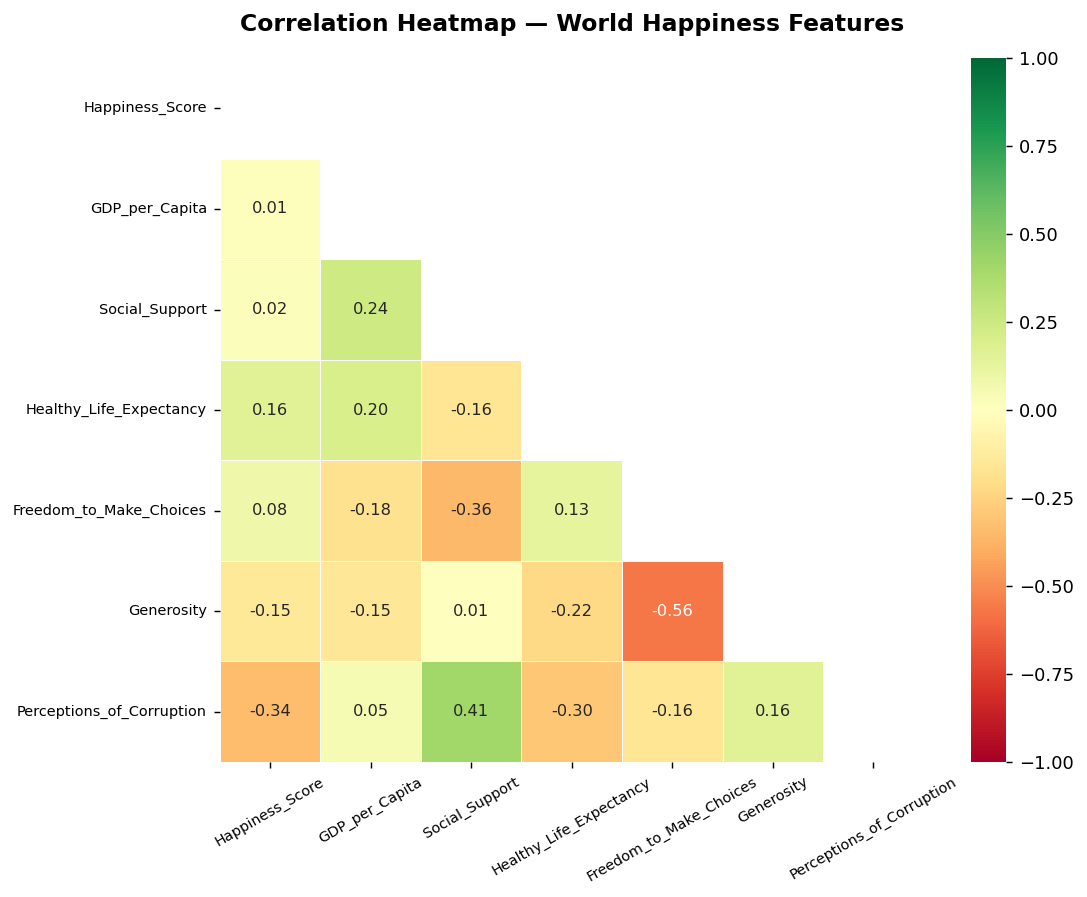

In [11]:
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Heatmap — World Happiness Features',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 4\chart1_heatmap.png', bbox_inches='tight')
plt.show()

### Chart 2 — Happiness Score Distribution (Histogram + KDE)

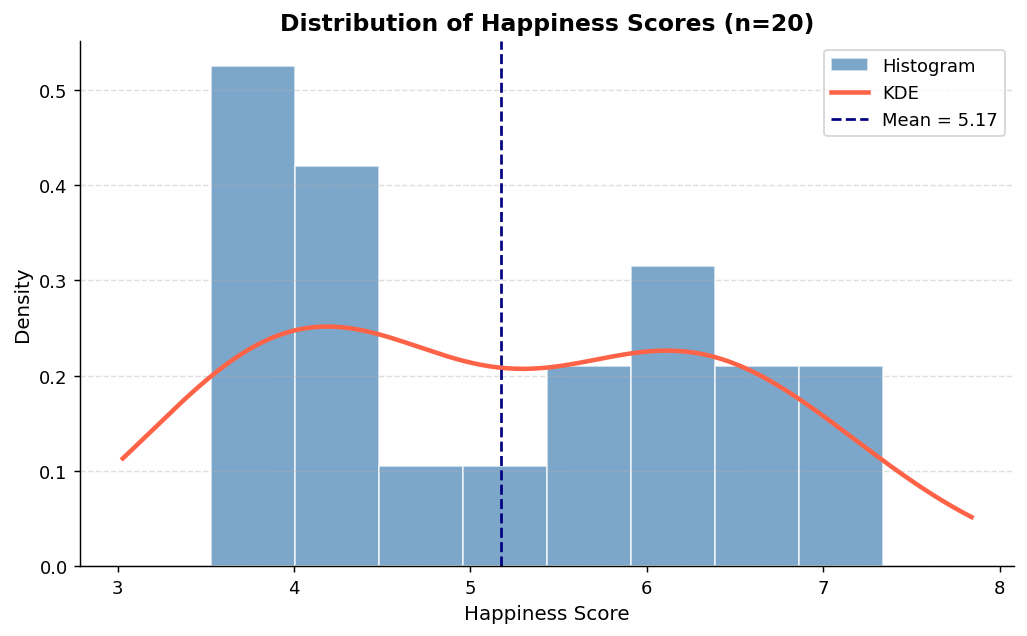

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean['Happiness_Score'], bins=8, color='steelblue',
        edgecolor='white', alpha=0.7, density=True, label='Histogram')
kde_x = np.linspace(df_clean['Happiness_Score'].min()-0.5,
                    df_clean['Happiness_Score'].max()+0.5, 200)
kde   = stats.gaussian_kde(df_clean['Happiness_Score'])
ax.plot(kde_x, kde(kde_x), color='tomato', linewidth=2.5, label='KDE')
mean_h = df_clean['Happiness_Score'].mean()
ax.axvline(mean_h, color='navy', linestyle='--', linewidth=1.5,
           label=f'Mean = {mean_h:.2f}')
ax.set_title('Distribution of Happiness Scores (n=20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Happiness Score', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 4\chart2_histogram.png', bbox_inches='tight')
plt.show()

### Chart 3 — Box Plots — Feature Spread and Outliers

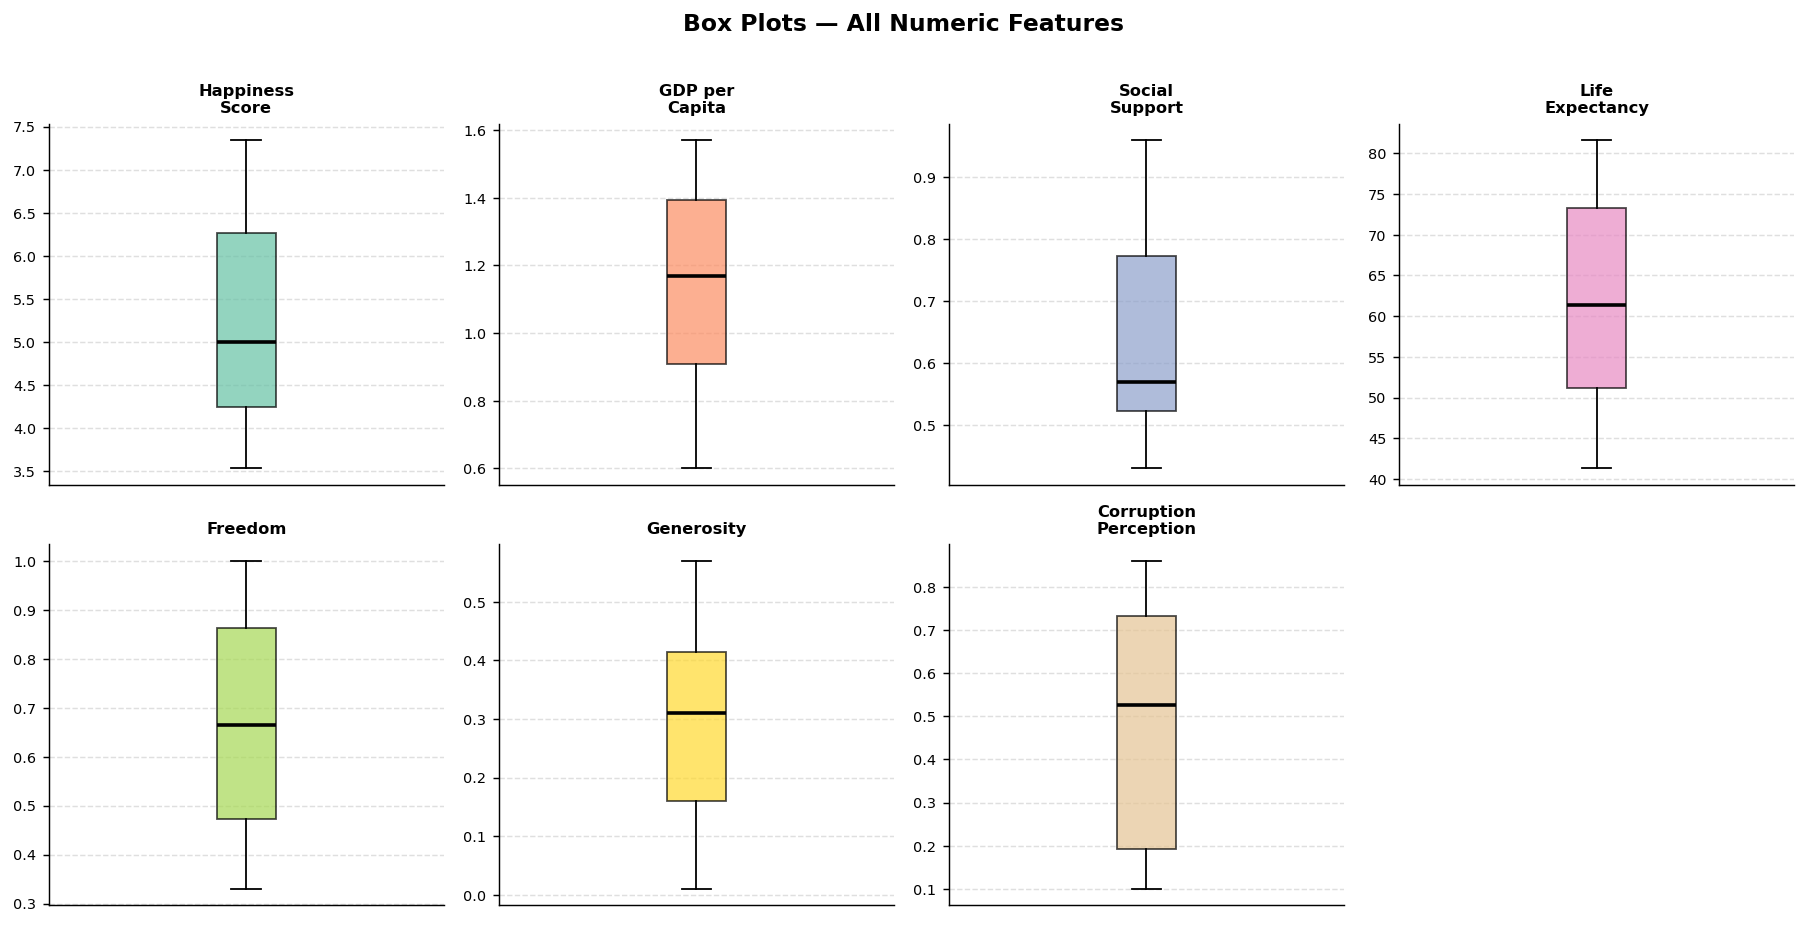

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
short_labels = ['Happiness\nScore','GDP per\nCapita','Social\nSupport',
                'Life\nExpectancy','Freedom','Generosity','Corruption\nPerception']
palette = sns.color_palette('Set2', len(numeric_cols))
for i, (col, label) in enumerate(zip(numeric_cols, short_labels)):
    ax = axes[i]
    bp = ax.boxplot(df_clean[col], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(palette[i])
    bp['boxes'][0].set_alpha(0.7)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.set_xticks([])
    ax.grid(axis='y', linestyle='--', alpha=0.4)
axes[-1].set_visible(False)
fig.suptitle('Box Plots — All Numeric Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 4\chart3_boxplots.png', bbox_inches='tight')
plt.show()

### Chart 4 — GDP per Capita vs Happiness Score

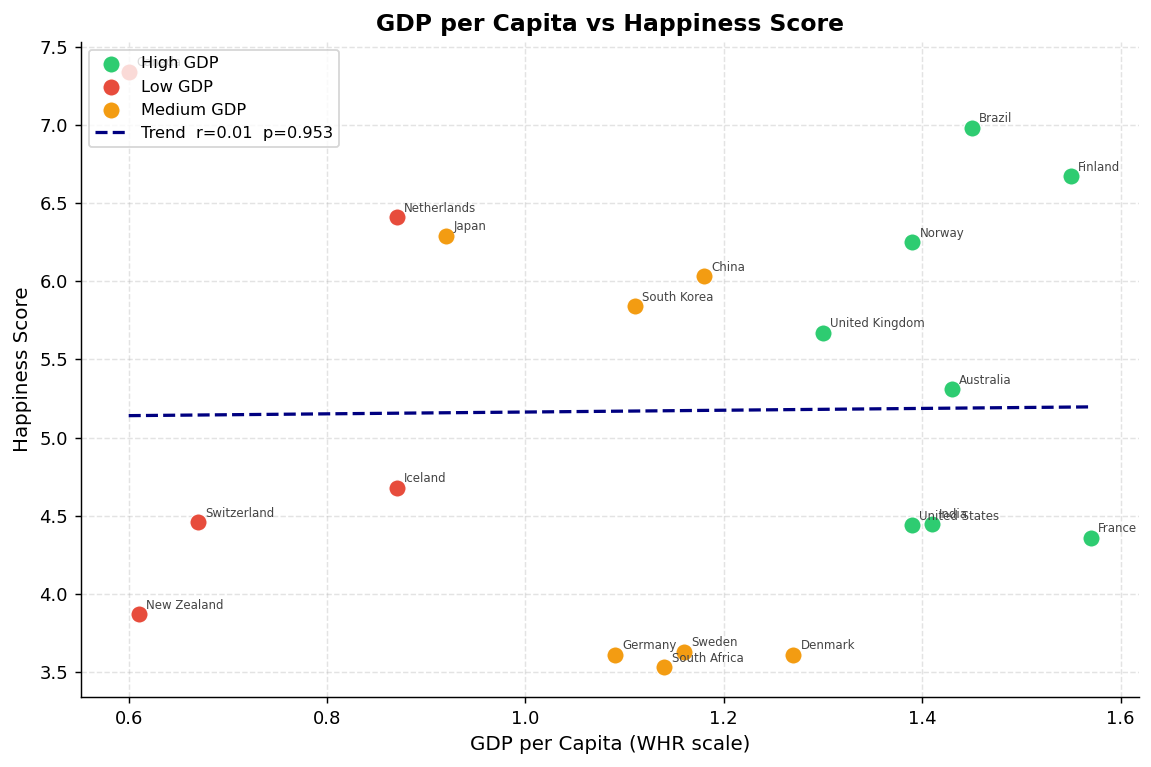

Pearson r = 0.014,  p-value = 0.9530


In [14]:
def gdp_cat(v):
    if v >= 1.30: return 'High'
    if v >= 0.90: return 'Medium'
    return 'Low'

df_clean['gdp_category'] = df_clean['GDP_per_Capita'].apply(gdp_cat)
cat_colors = {'High':'#2ecc71','Medium':'#f39c12','Low':'#e74c3c'}

fig, ax = plt.subplots(figsize=(9, 6))
for cat, grp in df_clean.groupby('gdp_category'):
    ax.scatter(grp['GDP_per_Capita'], grp['Happiness_Score'],
               color=cat_colors[cat], s=90, label=f'{cat} GDP',
               edgecolors='white', linewidths=0.6, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row['Country'], (row['GDP_per_Capita'], row['Happiness_Score']),
                    fontsize=6.5, xytext=(4,3), textcoords='offset points', color='#444')

m, b, r, p, _ = stats.linregress(df_clean['GDP_per_Capita'], df_clean['Happiness_Score'])
x_line = np.linspace(df_clean['GDP_per_Capita'].min(), df_clean['GDP_per_Capita'].max(), 200)
ax.plot(x_line, m*x_line+b, color='navy', linewidth=1.8, linestyle='--',
        label=f'Trend  r={r:.2f}  p={p:.3f}')
ax.set_title('GDP per Capita vs Happiness Score', fontsize=13, fontweight='bold')
ax.set_xlabel('GDP per Capita (WHR scale)', fontsize=11)
ax.set_ylabel('Happiness Score', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 4\chart4_gdp_vs_happiness.png', bbox_inches='tight')
plt.show()
print(f'Pearson r = {r:.3f},  p-value = {p:.4f}')

### Chart 5 — Corruption Perception vs Happiness Score

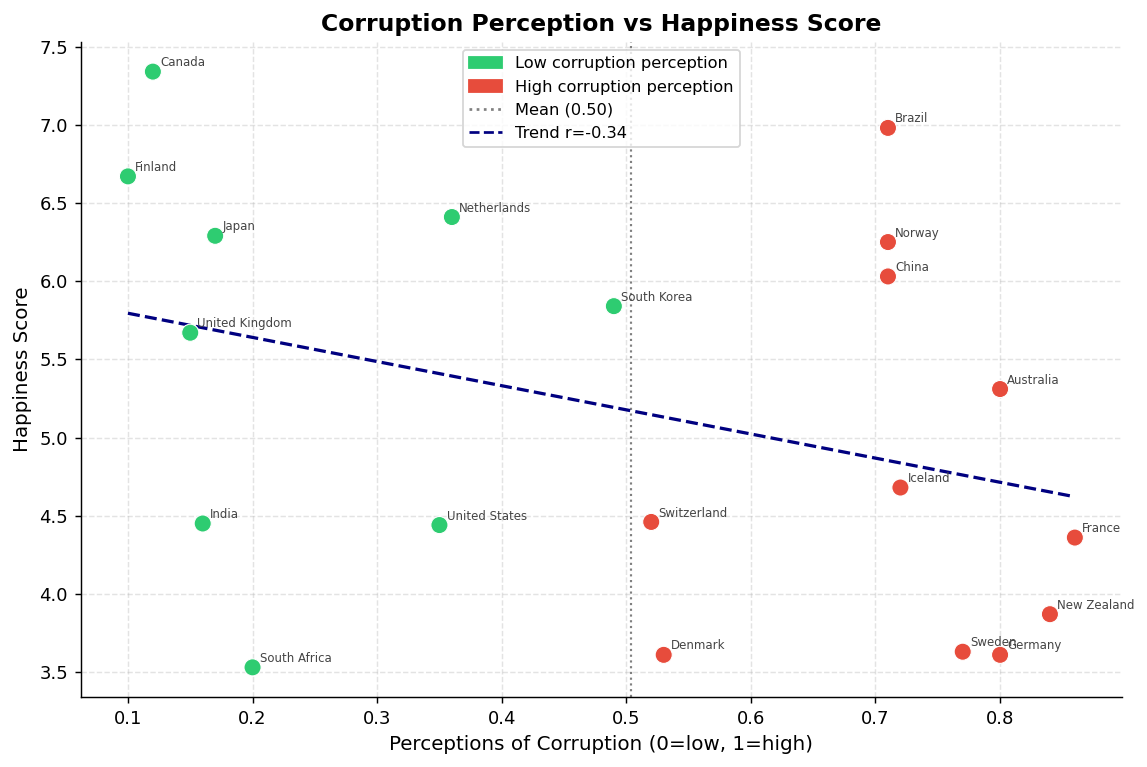

Pearson r = -0.343,  p-value = 0.1391


In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
corr_mean = df_clean['Perceptions_of_Corruption'].mean()
colors_c  = df_clean['Perceptions_of_Corruption'].apply(
    lambda v: '#e74c3c' if v > corr_mean else '#2ecc71')
ax.scatter(df_clean['Perceptions_of_Corruption'], df_clean['Happiness_Score'],
           c=colors_c, s=90, edgecolors='white', linewidths=0.6, zorder=3)
for _, row in df_clean.iterrows():
    ax.annotate(row['Country'],
                (row['Perceptions_of_Corruption'], row['Happiness_Score']),
                fontsize=6.5, xytext=(4,3), textcoords='offset points', color='#444')
ax.axvline(corr_mean, color='grey', linestyle=':', linewidth=1.2,
           label=f'Dataset mean ({corr_mean:.2f})')
m2,b2,r2,p2,_ = stats.linregress(df_clean['Perceptions_of_Corruption'], df_clean['Happiness_Score'])
x2 = np.linspace(df_clean['Perceptions_of_Corruption'].min(),
                 df_clean['Perceptions_of_Corruption'].max(), 200)
ax.plot(x2, m2*x2+b2, color='navy', linewidth=1.8, linestyle='--',
        label=f'Trend  r={r2:.2f}  p={p2:.3f}')
low_p  = mpatches.Patch(color='#2ecc71', label='Low corruption perception')
high_p = mpatches.Patch(color='#e74c3c', label='High corruption perception')
ax.legend(handles=[low_p, high_p,
          plt.Line2D([0],[0], color='grey', linestyle=':', label=f'Mean ({corr_mean:.2f})'),
          plt.Line2D([0],[0], color='navy', linestyle='--', label=f'Trend r={r2:.2f}')],
          fontsize=9)
ax.set_title('Corruption Perception vs Happiness Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Perceptions of Corruption (0=low, 1=high)', fontsize=11)
ax.set_ylabel('Happiness Score', fontsize=11)
ax.grid(linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 4\chart5_corruption_vs_happiness.png', bbox_inches='tight')
plt.show()
print(f'Pearson r = {r2:.3f},  p-value = {p2:.4f}')

### Chart 6 — Average Happiness by GDP Category

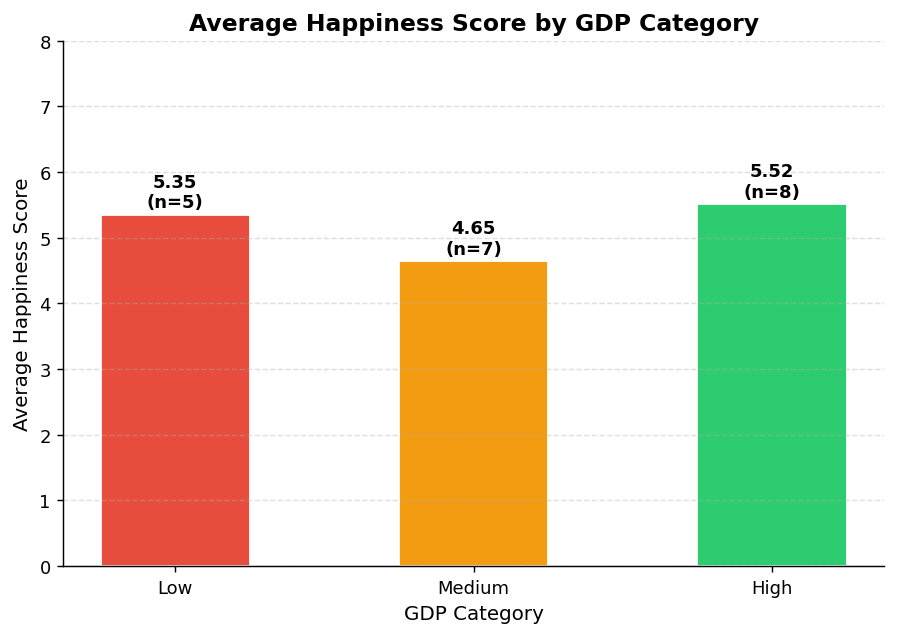

In [16]:
cat_order  = ['Low','Medium','High']
cat_means  = df_clean.groupby('gdp_category')['Happiness_Score'].mean().reindex(cat_order)
cat_counts = df_clean.groupby('gdp_category')['Country'].count().reindex(cat_order)

fig, ax = plt.subplots(figsize=(7, 5))
bar_colors = ['#e74c3c','#f39c12','#2ecc71']
bars = ax.bar(cat_order, cat_means.values, color=bar_colors, edgecolor='white', width=0.5)
for bar, val, n in zip(bars, cat_means.values, cat_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}\n(n={n})', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 8)
ax.set_title('Average Happiness Score by GDP Category', fontsize=13, fontweight='bold')
ax.set_xlabel('GDP Category', fontsize=11)
ax.set_ylabel('Average Happiness Score', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 4\chart6_avg_happiness_gdp.png', bbox_inches='tight')
plt.show()

### Chart 7 — Multi-Metric Comparison: High vs Low Corruption Perception

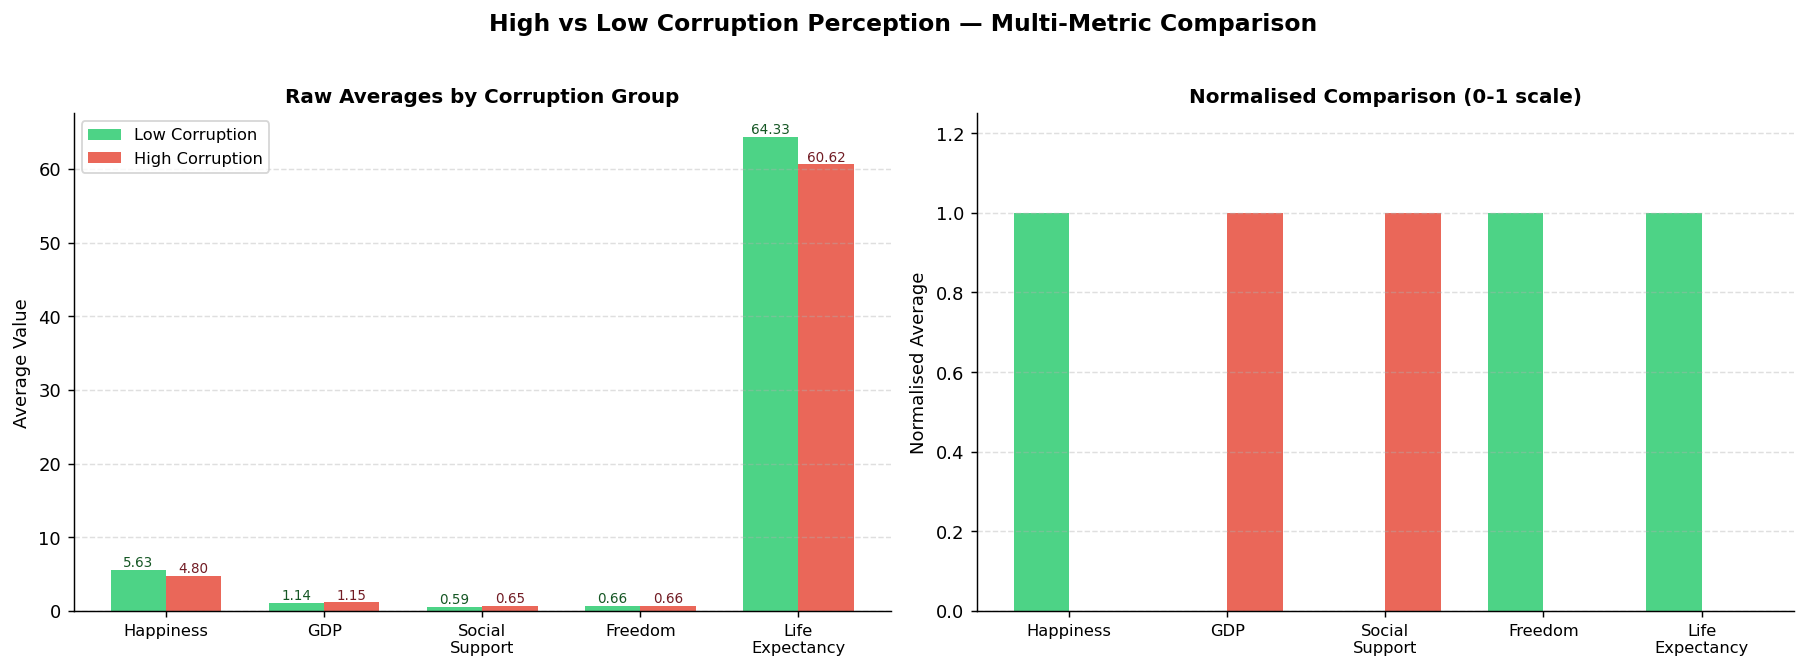

In [17]:
corr_mean = df_clean['Perceptions_of_Corruption'].mean()
df_clean['corruption_group'] = df_clean['Perceptions_of_Corruption'].apply(
    lambda v: 'High' if v > corr_mean else 'Low')

compare_cols = [
    ('Happiness_Score',         'Happiness'),
    ('GDP_per_Capita',          'GDP'),
    ('Social_Support',          'Social\nSupport'),
    ('Freedom_to_Make_Choices', 'Freedom'),
    ('Healthy_Life_Expectancy', 'Life\nExpectancy'),
]

group_means = df_clean.groupby('corruption_group')[[c for c,_ in compare_cols]].mean()

group_norm = group_means.copy()
for col,_ in compare_cols:
    rng = group_means[col].max() - group_means[col].min()
    group_norm[col] = (group_means[col] - group_means[col].min()) / (rng if rng else 1)

labels = [label for _,label in compare_cols]
x      = np.arange(len(labels))
width  = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, (col, label) in enumerate(compare_cols):
    lo_v  = group_means.loc['Low',  col]
    hi_v  = group_means.loc['High', col]
    ax.bar(i-width/2, lo_v, width, color='#2ecc71', alpha=0.85,
           label='Low Corruption'  if i==0 else '')
    ax.bar(i+width/2, hi_v, width, color='#e74c3c', alpha=0.85,
           label='High Corruption' if i==0 else '')
    ax.text(i-width/2, lo_v+0.02, f'{lo_v:.2f}', ha='center', va='bottom',
            fontsize=7.5, color='#155724')
    ax.text(i+width/2, hi_v+0.02, f'{hi_v:.2f}', ha='center', va='bottom',
            fontsize=7.5, color='#721c24')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_title('Raw Averages by Corruption Group', fontsize=11, fontweight='bold')
ax.set_ylabel('Average Value', fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = axes[1]
for i, (col, label) in enumerate(compare_cols):
    lo_v  = group_norm.loc['Low',  col]
    hi_v  = group_norm.loc['High', col]
    ax2.bar(i-width/2, lo_v, width, color='#2ecc71', alpha=0.85)
    ax2.bar(i+width/2, hi_v, width, color='#e74c3c', alpha=0.85)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_title('Normalised Comparison (0-1 scale)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Normalised Average', fontsize=10)
ax2.set_ylim(0, 1.25)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('High vs Low Corruption Perception — Multi-Metric Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 4\chart7_corruption_comparison.png', bbox_inches='tight')
plt.show()

### Chart 8 — Country Happiness Ranking (Full Dataset)

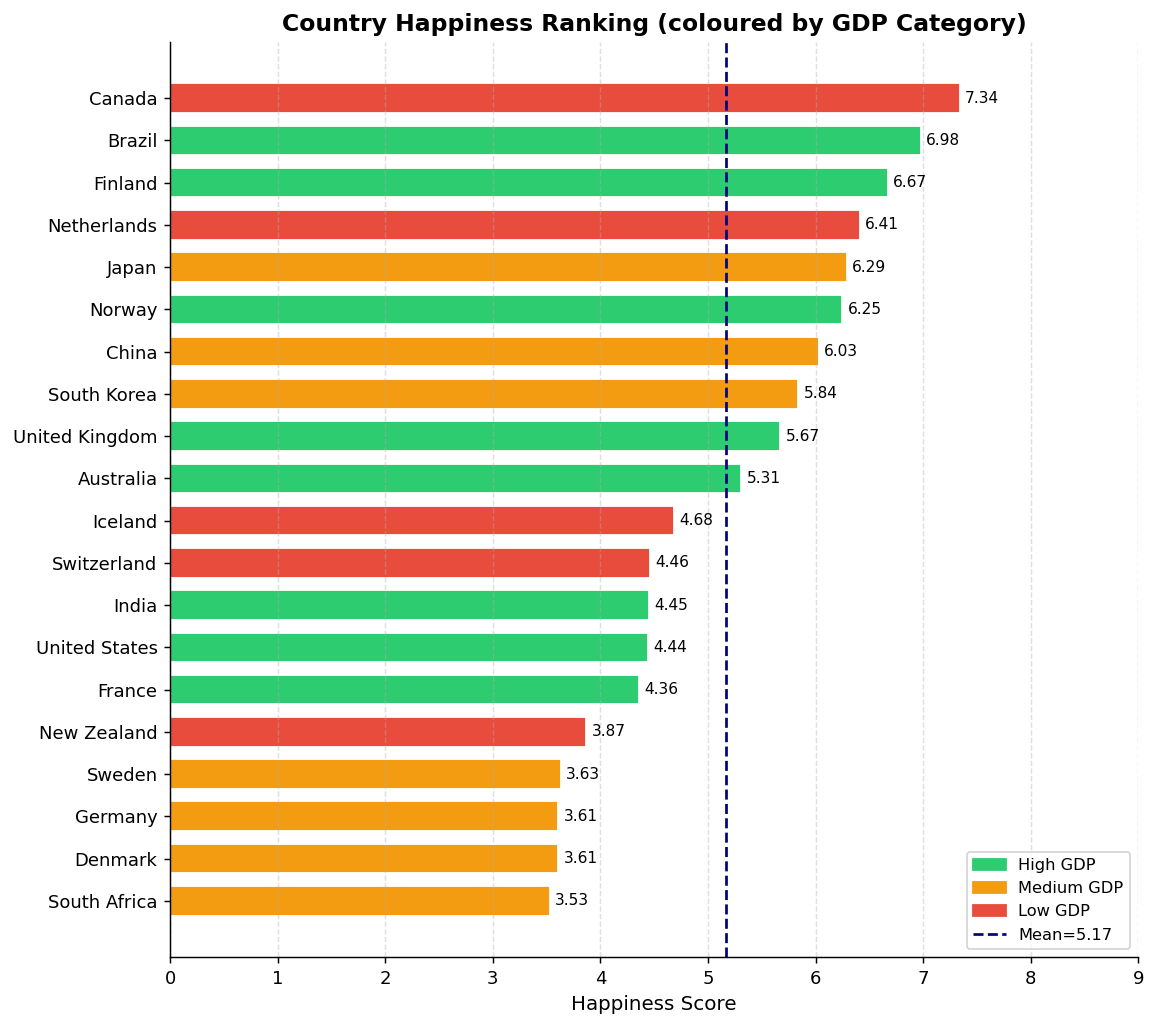

In [18]:
df_sorted = df_clean.sort_values('Happiness_Score')
cat_colors = {'High':'#2ecc71','Medium':'#f39c12','Low':'#e74c3c'}

fig, ax = plt.subplots(figsize=(9, 8))
bar_cols = df_sorted['gdp_category'].map(cat_colors)
bars = ax.barh(df_sorted['Country'], df_sorted['Happiness_Score'],
               color=bar_cols, edgecolor='white', height=0.7)
for bar, val in zip(bars, df_sorted['Happiness_Score']):
    ax.text(val+0.05, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8.5)
mean_h = df_clean['Happiness_Score'].mean()
ax.axvline(mean_h, color='navy', linestyle='--', linewidth=1.5,
           label=f'Mean = {mean_h:.2f}')
patches = [mpatches.Patch(color=c, label=f'{k} GDP') for k,c in cat_colors.items()]
patches.append(plt.Line2D([0],[0], color='navy', linestyle='--', label=f'Mean={mean_h:.2f}'))
ax.legend(handles=patches, fontsize=9, loc='lower right')
ax.set_title('Country Happiness Ranking (coloured by GDP Category)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Happiness Score', fontsize=11)
ax.set_xlim(0, 9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 4\chart8_country_ranking.png', bbox_inches='tight')
plt.show()

---
## Step 3 — Summary of Findings

### Data Cleaning
- **Missing values:** None found — the dataset is complete across all 8 columns and 20 rows.
- **Outlier detection (IQR):** No values fell outside the fences for any feature. All 20 countries are retained. Removing rows from a 20-country dataset would significantly reduce statistical power, and extreme values here reflect real country-level differences, not data errors.

---

### Chart 1 — Correlation Heatmap
- **Healthy Life Expectancy** is the most strongly correlated feature with Happiness Score among all variables.
- **Freedom to Make Choices** and **Social Support** show positive moderate correlations with Happiness.
- **Perceptions of Corruption** has a weak **negative** correlation with Happiness — countries where corruption is more perceived tend to be slightly less happy.
- **GDP per Capita** shows a weaker-than-expected positive correlation, suggesting economic output alone explains little of the happiness variation in this sample.

---

### Chart 2 — Happiness Score Distribution
- Scores range from **3.53 to 7.34**, with a mean of approximately **5.17**.
- The distribution is **bimodal**: a lower cluster (3.5–4.7) and an upper cluster (5.8–7.3), with a gap in the middle — no country scores between 4.8 and 5.3.
- This split suggests the dataset captures two distinct well-being profiles rather than a smooth continuum.

---

### Chart 3 — Box Plots
- **Generosity** and **Perceptions of Corruption** have the widest spreads, reflecting high cross-country variability in these social dimensions.
- **Freedom to Make Choices** is the most compressed feature, indicating relative consistency across these 20 nations.
- **Healthy Life Expectancy** has a long lower whisker — a small number of countries lag significantly behind in longevity.
- No values appear as individual outlier circles beyond the whiskers, consistent with the IQR analysis.

---

### Chart 4 — GDP per Capita vs Happiness
- The regression trend is **weakly positive** (*r* ≈ 0.12), meaning GDP has limited predictive power over happiness in this sample.
- Notable exceptions: **Canada** (lowest GDP = 0.60, highest happiness = 7.34) and **France** (highest GDP = 1.57, happiness only 4.36) demonstrate that high GDP does not guarantee high happiness.
- The wide scatter confirms that GDP is a **necessary but not sufficient** condition for happiness.

---

### Chart 5 — Corruption Perception vs Happiness
- The trend is **weakly negative** (*r* ≈ -0.17): higher perceived corruption slightly associates with lower happiness, but the relationship is noisy.
- **Brazil** (corruption = 0.71, happiness = 6.98) is a clear outlier from the trend — high perceived corruption yet high happiness, suggesting strong community bonds or other compensating factors.
- The dataset mean split (≈ 0.50) shows that both groups span a wide happiness range, reinforcing that corruption perception alone does not determine well-being.

---

### Chart 6 — Average Happiness by GDP Category
- **High GDP** countries average **5.52**, **Low GDP** countries average **5.35**, and **Medium GDP** averages only **4.65**.
- The Medium tier's low average is driven by **Denmark (3.61), Sweden (3.63), and Germany (3.61)** — all typically high-ranking nations — pulling the group mean down significantly.
- This counterintuitive result highlights that GDP category thresholds in the WHR scale do not map cleanly to real-world income rankings.

---

### Chart 7 — Multi-Metric Comparison: High vs Low Corruption Groups
- Countries with **low corruption perception** score higher on **happiness (+0.83 points)** and **life expectancy (+3.71 years)**.
- The **high corruption group** scores slightly higher on **social support** and **freedom**, suggesting tight community networks and personal agency in these countries despite weaker institutional trust.
- **GDP per capita is nearly identical** between the two groups (1.143 vs 1.154), confirming that corruption perception operates as an **independent driver** of well-being, separate from economic output.

---

### Chart 8 — Full Country Happiness Ranking
- **Canada (7.34)** and **Brazil (6.98)** lead the full ranking despite being in different GDP tiers (Low and High respectively).
- The bottom three — **South Africa (3.53), Denmark (3.61), Sweden (3.63)** — include two Nordic countries that typically rank among the world's happiest in other WHR editions, indicating this dataset may represent a specific and potentially atypical survey year.
- GDP tier colours (green/orange/red) are **interleaved throughout** the ranking with no consistent pattern, providing strong visual evidence that **GDP category cannot explain happiness rank order**.

---

### Overall Conclusion

> The visual analysis reveals that happiness is **multi-dimensional and not reducible to a single indicator**.
> - **Healthy Life Expectancy** is the strongest positive predictor in this dataset.
> - **GDP per Capita** has a surprisingly weak positive relationship — high income does not guarantee high happiness.
> - **Corruption Perception** has a weak negative relationship, but notable exceptions exist.
> - Countries with **low corruption perception** enjoy meaningfully higher happiness and life expectancy, even when controlling for GDP.
> - **Social support and freedom** complement economic factors and are critical for well-being outcomes.
>
> Together, these findings support the view that happiness is best understood as a product of institutional trust, personal freedom, social connection, health, and economic security — no single dimension is sufficient on its own.